## 多尺度可变形注意力总结

### 核心思想

多尺度可变形注意力（Multi-Scale Deformable Attention）旨在解决标准 Transformer 全局注意力计算量大、难以处理多尺度特征的问题。它让每个 query 只需关注**少数几个可学习的采样点**，这些点分布在多个不同分辨率的特征图上，从而高效地聚合多尺度上下文信息。其关键特性：

- **稀疏采样**：每个 query 只采样 `n_heads × n_levels × n_points` 个点，而非整个特征图。
- **可变形性**：采样位置由参考点 + 学习到的偏移决定，可以适应物体形状和尺度变化。
- **跨尺度融合**：每个 query 会在所有特征层上进行采样，并将多层特征加权融合。
- **无显式 Key**：注意力权重由 query 直接回归得到，而非通过 query-key 相似度计算。

---

### 数学描述

设：
- Query 特征：$ \mathbf{q} \in \mathbb{R}^{N \times L_q \times C} $，其中 $N$ 为 batch size，$L_q$ 为 query 数量，$C$ 为特征维度。
- 多尺度 Value 特征：$ \mathbf{v} \in \mathbb{R}^{N \times L_{in} \times C} $，其中 $L_{in} = \sum_{l=1}^{L} H_l W_l$，$L$ 为特征层数。
- 参考点：$ \mathbf{p} \in \mathbb{R}^{N \times L_q \times L \times 2} $，归一化坐标，表示每个 query 在每个特征层上的初始采样中心。
- 注意力头数：$M$，每个头维度 $d = C / M$。
- 每个头在每层的采样点数：$P$。

#### 1. 从 Query 预测偏移和权重

通过线性层得到：
$$
\Delta \mathbf{p} = \text{Linear}_{\text{offset}}(\mathbf{q}) \in \mathbb{R}^{N \times L_q \times M \times L \times P \times 2}
$$
$$
\mathbf{A} = \text{softmax}\big( \text{Linear}_{\text{attn}}(\mathbf{q}) \big) \in \mathbb{R}^{N \times L_q \times M \times L \times P}
$$
其中 $\Delta \mathbf{p}_{n,m,l,p,:} = (\Delta x, \Delta y)$ 表示第 $n$ 个样本、第 $q$ 个 query、第 $m$ 个头、第 $l$ 层、第 $p$ 个采样点的偏移；$\mathbf{A}_{n,q,m,l,p}$ 为对应注意力权重，满足 $\sum_p \mathbf{A}_{n,q,m,l,p} = 1$（对同一 query 在同一层同头的所有采样点）。

#### 2. 计算实际采样位置

采样位置由参考点加上归一化偏移得到。设第 $l$ 层特征图尺寸为 $(H_l, W_l)$，则：
$$
\mathbf{s}_{n,q,m,l,p} = \mathbf{p}_{n,q,l} + \frac{\Delta \mathbf{p}_{n,q,m,l,p}}{\mathbf{s}_{l}}
$$
其中 $\mathbf{s}_l = (W_l, H_l)$ 为归一化因子，用于将像素偏移转换为归一化坐标偏移（保持坐标在 $[0,1]$ 内）。若参考点包含宽高（参考框模式），则偏移会乘以框宽高的一半，这里略。

#### 3. 采样 Value

使用双线性插值从对应层的 Value 特征图上采样：
$$
\mathbf{v}_{n,m,l,p} = \text{grid\_sample}\big( \mathbf{V}_l, \mathbf{s}_{n,m,l,p} \big) \in \mathbb{R}^{d}
$$
其中 $\mathbf{V}_l$ 为第 $l$ 层特征图（投影后按头拆分），$\mathbf{v}_{n,m,l,p}$ 为采样得到的头特征。

#### 4. 加权求和

每个 query 在每个头下的输出为所有采样点的加权和：
$$
\mathbf{o}_{n,q,m} = \sum_{l=1}^{L} \sum_{p=1}^{P} \mathbf{A}_{n,q,m,l,p} \cdot \mathbf{v}_{n,q,m,l,p}
$$
其中 $\mathbf{v}_{n,q,m,l,p}$ 是上一步采样结果（与 query 索引对应）。

#### 5. 合并多头与输出投影

将各头输出拼接，再通过线性层得到最终输出：
$$
\mathbf{O}_{n,q} = \mathbf{W}_o \left[ \mathbf{o}_{n,q,1}; \mathbf{o}_{n,q,2}; \dots; \mathbf{o}_{n,q,M} \right] \in \mathbb{R}^{C}
$$
其中 $\mathbf{W}_o$ 为输出投影矩阵，$[\cdot;\cdot]$ 表示向量拼接。

---

### 与标准注意力的对比

| 标准注意力 | 多尺度可变形注意力 |
|-----------|-------------------|
| 注意力权重来自 $Q$ 与 $K$ 的点积 | 注意力权重由 $Q$ 直接回归 |
| 每个 query 关注所有位置 | 每个 query 只关注少数采样点 |
| 单一特征尺度 | 多尺度特征图 |
| 计算复杂度 $O(L_q \cdot L_{in})$ | 计算复杂度 $O(L_q \cdot M \cdot L \cdot P)$，与特征图大小解耦 |

这种设计使模型能够高效处理高分辨率多尺度特征，同时保持灵活性，显著提升了 DETR 类检测器的收敛速度和小目标性能。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.init import xavier_uniform_, constant_
import math


class MSDeformAttn(nn.Module):
    """
    多尺度可变形注意力模块（纯 PyTorch 实现，便于理解和调试）

    与标准注意力不同，这里没有显式的 Key，注意力权重由 Query 直接预测得到。
    Query 通过一个线性层同时输出采样偏移量和注意力权重。
    采样过程在多尺度特征图的每一层上独立进行，使用双线性插值（F.grid_sample）获取特征，
    最后将所有采样点的特征加权求和，得到每个 Query 的输出。
    """

    def __init__(self, d_model=256, n_levels=4, n_heads=8, n_points=4):
        """
        参数:
            d_model: 特征维度（默认 256）
            n_levels: 多尺度特征层数（默认 4）
            n_heads: 注意力头数（默认 8）
            n_points: 每个头在每层上的采样点数（默认 4）
        """
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_levels = n_levels
        self.n_heads = n_heads
        self.n_points = n_points
        self.d_head = d_model // n_heads  # 每个头的维度

        # 合并的线性层：同时预测采样偏移和注意力权重
        # 对每个头、每个层、每个采样点，需要输出 2 个坐标偏移 + 1 个注意力权重 = 3 个值
        # 因此输出维度 = n_heads * n_levels * n_points * 3
        self.sampling_offsets_attn = nn.Linear(
            d_model, n_heads * n_levels * n_points * 3
        )
        # 对 value 进行线性投影（可学习变换）
        self.value_proj = nn.Linear(d_model, d_model)
        # 输出投影层，将融合后的特征映射回 d_model 维度
        self.output_proj = nn.Linear(d_model, d_model)

        self._reset_parameters()

    def _reset_parameters(self):
        """
        参数初始化，保持与原版 Deformable DETR 一致。
        采样偏移的 bias 初始化为围绕参考点的放射状分布，
        注意力权重的 bias 初始化为 0，权重初始化为 0。
        """
        # 采样偏移和注意力权重的线性层权重全部初始化为 0
        constant_(self.sampling_offsets_attn.weight.data, 0.)

        # 生成初始采样偏移 bias：让每个头的初始采样点呈放射状分布
        # thetas: 每个头对应的角度（均匀分布在圆周上）
        thetas = torch.arange(self.n_heads, dtype=torch.float32) * (2.0 * math.pi / self.n_heads)
        grid_init = torch.stack([thetas.cos(), thetas.sin()], -1)  # (n_heads, 2)
        # 归一化，使最大值为 1
        grid_init = (grid_init / grid_init.abs().max(-1, keepdim=True)[0]).view(
            self.n_heads, 1, 1, 2
        ).repeat(1, self.n_levels, self.n_points, 1)  # (n_heads, n_levels, n_points, 2)
        # 不同采样点距离参考点远近不同（乘以 i+1 增加半径）
        for i in range(self.n_points):
            grid_init[:, :, i, :] *= i + 1

        # 合并的 bias：前半部分是采样偏移 bias，后半部分是注意力权重 bias（全 0）
        bias = torch.cat([
            grid_init.view(-1),  # 采样偏移部分
            torch.zeros(self.n_heads * self.n_levels * self.n_points)  # 注意力权重部分
        ])
        with torch.no_grad():
            self.sampling_offsets_attn.bias = nn.Parameter(bias)

        # value 投影层使用 Xavier 初始化
        xavier_uniform_(self.value_proj.weight.data)
        constant_(self.value_proj.bias.data, 0.)
        # 输出投影层使用 Xavier 初始化
        xavier_uniform_(self.output_proj.weight.data)
        constant_(self.output_proj.bias.data, 0.)

    def forward(self, query, reference_points, input_flatten, input_spatial_shapes,
                input_level_start_index, input_padding_mask=None):
        """
        前向传播

        参数:
            query: (N, Lq, C)
                N: batch size
                Lq: query 数量（编码器中为所有像素数，解码器中为 object queries 数）
                C: 特征维度（d_model）
            reference_points: (N, Lq, n_levels, 2)
                每个 query 在每个特征层上的参考点，坐标为归一化坐标 [0, 1]。
                该坐标相对于整个特征图（包括 padding），因此在采样时需注意偏移归一化。
            input_flatten: (N, L_in, C)
                多尺度特征图展平并拼接后的结果，L_in = sum(H_l * W_l)
            input_spatial_shapes: (n_levels, 2)
                每个特征层的 (H, W)
            input_level_start_index: (n_levels,)
                每个特征层在 input_flatten 中的起始索引，用于按层拆分
            input_padding_mask: (N, L_in) 或 None
                标记哪些位置是 padding（True 表示 padding），用于屏蔽无效区域

        返回:
            output: (N, Lq, C)
                每个 query 经过多尺度可变形注意力后的特征
        """
        N, Lq, _ = query.shape
        N, L_in, C = input_flatten.shape
        assert (input_spatial_shapes[:, 0] * input_spatial_shapes[:, 1]).sum() == L_in, \
            "input_spatial_shapes 与 input_flatten 长度不一致"

        # ---------- 1. 投影 value 并屏蔽 padding ----------
        # value 是实际被采样的特征，来自输入的多尺度特征图
        value = self.value_proj(input_flatten)  # (N, L_in, C)
        if input_padding_mask is not None:
            # 将 padding 位置的特征置为 0，避免影响后续采样
            value = value.masked_fill(input_padding_mask[..., None], 0.)
        # 将 value 按照头拆分： (N, L_in, n_heads, d_head)
        value = value.view(N, L_in, self.n_heads, self.d_head)

        # ---------- 2. 从 query 生成采样偏移和注意力权重 ----------
        # 通过合并的线性层得到所有头、所有层、所有采样点的偏移和权重
        offsets_attn = self.sampling_offsets_attn(query)  # (N, Lq, n_heads*n_levels*n_points*3)
        # 重塑为 (N, Lq, n_heads, n_levels, n_points, 3)
        offsets_attn = offsets_attn.view(N, Lq, self.n_heads, self.n_levels, self.n_points, 3)
        # 前两个元素为采样偏移 (Δx, Δy)
        sampling_offsets = offsets_attn[..., :2]  # (N, Lq, n_heads, n_levels, n_points, 2)
        # 第三个元素为注意力权重
        attention_weights = offsets_attn[..., 2]  # (N, Lq, n_heads, n_levels, n_points)
        # 对每个 query 的所有采样点权重进行 softmax 归一化
        attention_weights = F.softmax(attention_weights, dim=-1)  # 最后一维为 n_points

        # ---------- 3. 计算实际采样位置 ----------
        # 采样位置 = 参考点 + 偏移量 / 特征图尺寸
        # 偏移量是像素级别的，需要除以特征图宽高得到归一化偏移（保持在 [0,1] 范围内）
        # 注意 input_spatial_shapes 的形状为 (n_levels, 2)，列为 (H, W)，但 grid_sample 使用 (x, y) = (W, H)
        offset_normalizer = torch.stack(
            [input_spatial_shapes[..., 1], input_spatial_shapes[..., 0]], dim=-1
        )  # (n_levels, 2)，顺序为 (W, H)
        # reference_points 形状 (N, Lq, n_levels, 2)，扩展为 (N, Lq, 1, n_levels, 1, 2)
        # sampling_offsets 形状 (N, Lq, n_heads, n_levels, n_points, 2)
        # 广播相加得到采样坐标 (N, Lq, n_heads, n_levels, n_points, 2)
        sampling_locations = (
            reference_points[:, :, None, :, None, :]  # 增加头维度和采样点维度
            + sampling_offsets / offset_normalizer[None, None, None, :, None, :]
        )

        # ---------- 4. 逐层采样 ----------
        # 因为不同层的特征图尺寸不同，无法直接合并为一次 grid_sample，所以循环处理每一层
        sampling_value_list = []
        for lid in range(self.n_levels):
            # 获取当前层的特征图尺寸和起始索引
            H_l, W_l = input_spatial_shapes[lid]
            start = input_level_start_index[lid]
            end = start + H_l * W_l

            # 从 value 中提取当前层的特征： (N, H_l*W_l, n_heads, d_head)
            value_l = value[:, start:end]
            # 重塑为 (N, n_heads, d_head, H_l, W_l) 然后合并 batch 和头维度
            # 这样每个 (head, batch) 对作为一个独立的样本，方便使用 grid_sample
            value_l = value_l.permute(0, 2, 3, 1)  # (N, n_heads, d_head, H_l*W_l)
            value_l = value_l.reshape(N * self.n_heads, self.d_head, H_l, W_l)

            # 获取当前层的采样网格坐标： (N, Lq, n_heads, n_points, 2)
            grid_l = sampling_locations[:, :, :, lid]  # (N, Lq, n_heads, n_points, 2)
            # 调整维度顺序以匹配 grid_sample 的输入要求：
            # grid_sample 需要 grid 形状为 (N', H_out, W_out, 2)，这里我们采样点数为 Lq * n_points
            # 将 batch 和头合并，query 和采样点数作为空间维度：
            # (N, Lq, n_heads, n_points, 2) -> (N, n_heads, Lq, n_points, 2) -> (N*n_heads, Lq, n_points, 2)
            grid_l = grid_l.permute(0, 2, 1, 3, 4).reshape(N * self.n_heads, Lq, self.n_points, 2)

            # grid_sample 要求坐标在 [-1, 1] 范围内，其中 -1 对应左上角，1 对应右下角
            # 我们的坐标是 [0, 1]，因此进行线性映射：x -> 2x - 1
            grid_l = 2.0 * grid_l - 1.0

            # 使用双线性插值采样，padding_mode='zeros' 表示越界部分填充 0
            sampled = F.grid_sample(
                value_l,              # 输入特征图 (N*n_heads, C, H, W)
                grid_l,               # 采样网格 (N*n_heads, Lq, n_points, 2)
                mode='bilinear',
                padding_mode='zeros',
                align_corners=False
            )  # 输出形状 (N*n_heads, d_head, Lq, n_points)

            # 将采样结果重塑回 (N, Lq, n_heads, n_points, d_head)
            sampled = sampled.view(N, self.n_heads, self.d_head, Lq, self.n_points)
            sampled = sampled.permute(0, 3, 1, 4, 2)  # (N, Lq, n_heads, n_points, d_head)

            sampling_value_list.append(sampled)

        # ---------- 5. 堆叠所有层的采样结果 ----------
        # 将各层结果在层维度拼接： (N, Lq, n_heads, n_levels, n_points, d_head)
        sampling_values = torch.stack(sampling_value_list, dim=3)

        # ---------- 6. 加权求和 ----------
        # 注意力权重形状 (N, Lq, n_heads, n_levels, n_points)，增加最后一维用于广播
        attention_weights = attention_weights.unsqueeze(-1)  # (N, Lq, n_heads, n_levels, n_points, 1)
        # 采样特征与对应权重相乘，然后在层和采样点维度求和
        output = (sampling_values * attention_weights).sum(dim=(3, 4))  # (N, Lq, n_heads, d_head)

        # ---------- 7. 合并多头并投影输出 ----------
        output = output.reshape(N, Lq, self.d_model)  # (N, Lq, d_model)
        output = self.output_proj(output)  # (N, Lq, d_model)

        return output

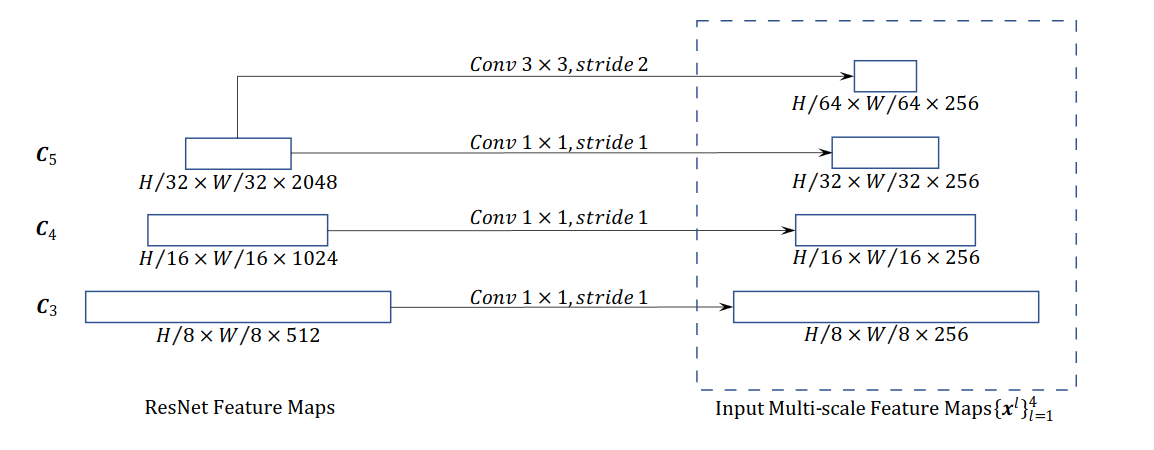  
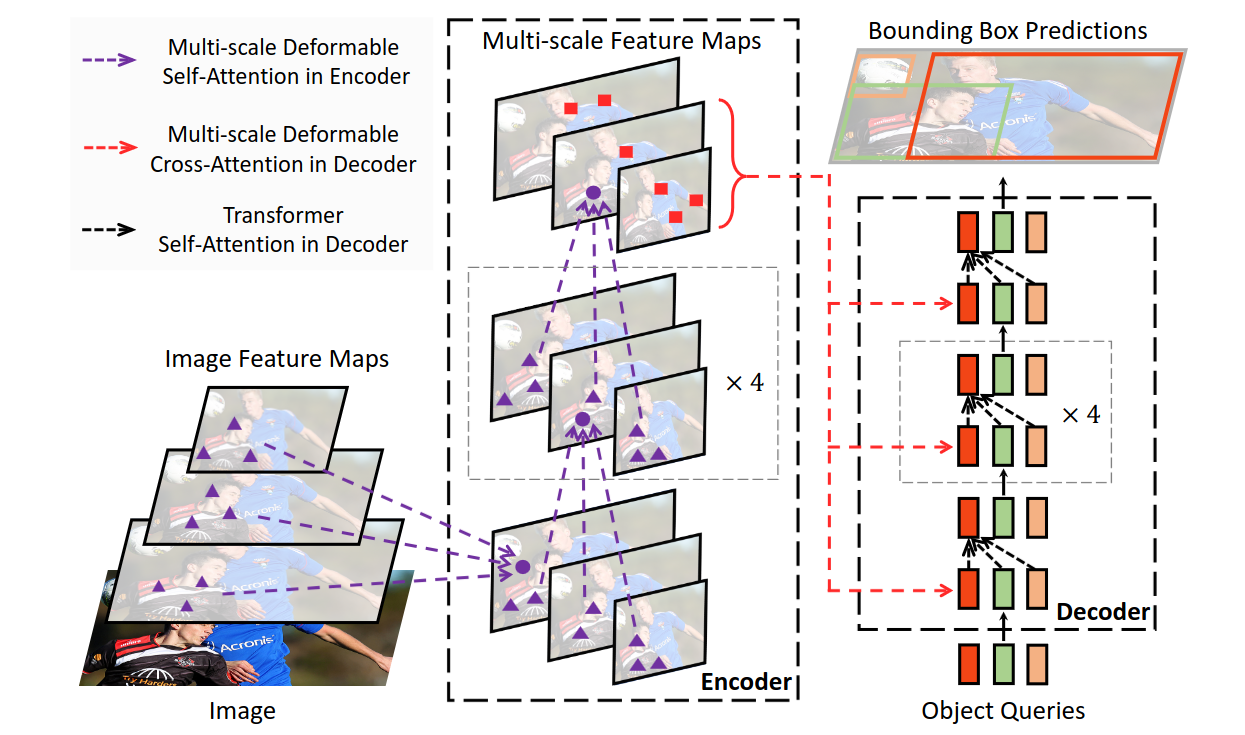  
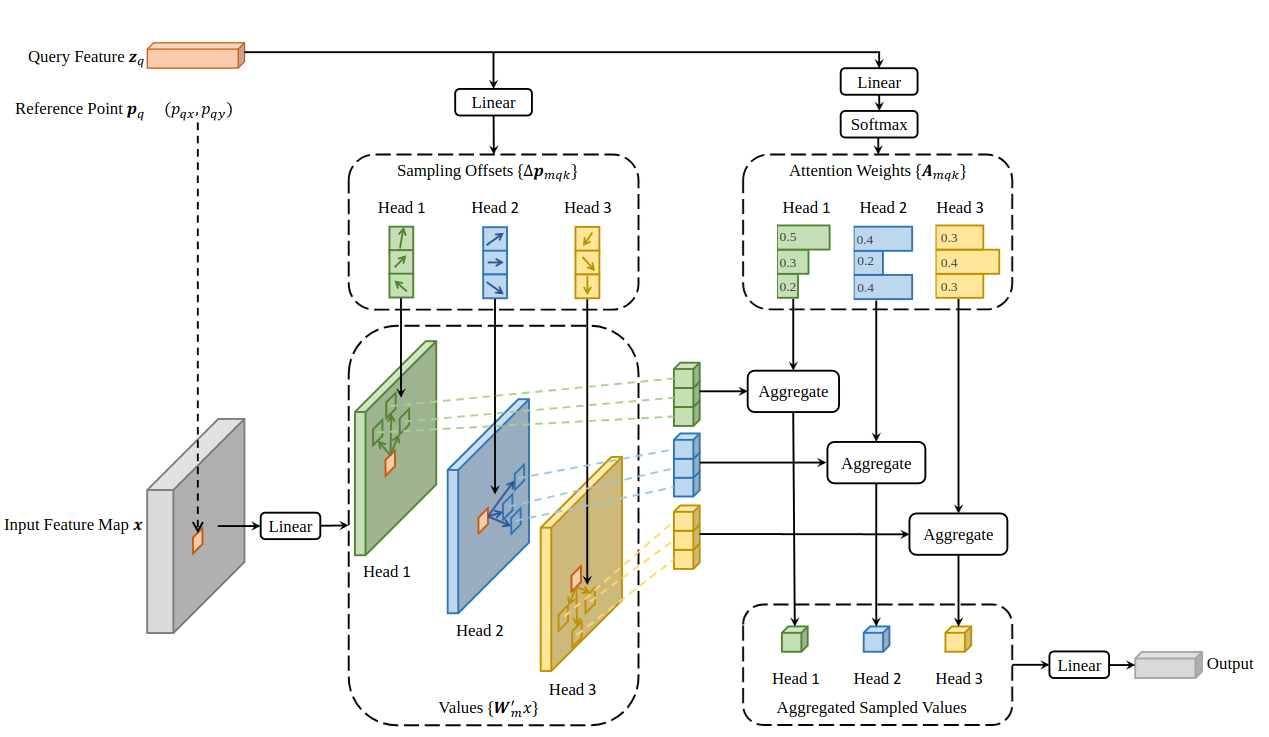

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import List, Optional

# ==============================================================
# 位置编码（正弦编码）
# ==============================================================
class PositionEmbeddingSine(nn.Module):
    """
    正弦位置编码，为每个像素生成唯一的位置向量。
    输入 mask 标记 padding（True 表示无效），位置编码只在有效区域内归一化，
    使得不同尺寸图像的有效区域坐标范围一致。
    """
    def __init__(self, num_pos_feats=128, temperature=10000, normalize=True, scale=2 * math.pi):
        super().__init__()
        self.num_pos_feats = num_pos_feats          # 位置编码特征维度的一半（最终输出维度 = 2 * num_pos_feats）
        self.temperature = temperature
        self.normalize = normalize
        self.scale = scale

    def forward(self, mask):
        """
        参数:
            mask: (N, H, W) bool，True 表示 padding 像素，False 表示有效像素
        返回:
            pos: (N, 2*num_pos_feats, H, W) 位置编码，维度为 d_model
        """
        not_mask = ~mask  # 有效区域为 True, 形状不变: (N, H, W)
        # 行方向累积和，得到 y 坐标（从 1 开始计数）
        y_embed = not_mask.cumsum(1, dtype=torch.float32)  # (N, H, W) -> 每行像素累计，得到行号
        # 列方向累积和，得到 x 坐标
        x_embed = not_mask.cumsum(2, dtype=torch.float32)  # (N, H, W) -> 每列像素累计，得到列号

        if self.normalize:
            eps = 1e-6
            # 归一化到 [0, scale] 区间，并居中
            # y_embed[:, -1:, :] 是每个 batch 每列的最大有效行数
            y_embed = (y_embed - 0.5) / (y_embed[:, -1:, :] + eps) * self.scale  # (N, H, W)
            x_embed = (x_embed - 0.5) / (x_embed[:, :, -1:] + eps) * self.scale  # (N, H, W)

        # 生成频率因子
        dim_t = torch.arange(self.num_pos_feats, dtype=torch.float32, device=mask.device)
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.num_pos_feats)  # (num_pos_feats,)

        # 对 x 和 y 坐标分别计算正弦/余弦编码
        pos_x = x_embed[:, :, :, None] / dim_t      # (N, H, W, num_pos_feats) 广播除法
        pos_y = y_embed[:, :, :, None] / dim_t      # (N, H, W, num_pos_feats)

        # 将最后一个维度的特征按奇偶索引分别取 sin 和 cos，然后合并
        # 例如: 对于 0::2 的索引（0,2,4,...）取 sin，1::2 的索引（1,3,5,...）取 cos
        pos_x = torch.stack((pos_x[..., 0::2].sin(), pos_x[..., 1::2].cos()), dim=4).flatten(3)
        # pos_x 形状: (N, H, W, num_pos_feats/2, 2) -> flatten(3) -> (N, H, W, num_pos_feats)
        pos_y = torch.stack((pos_y[..., 0::2].sin(), pos_y[..., 1::2].cos()), dim=4).flatten(3)
        # 同上

        # 拼接 y 和 x，并调整维度为 (N, C, H, W)，其中 C = 2 * num_pos_feats
        pos = torch.cat((pos_y, pos_x), dim=3).permute(0, 3, 1, 2)
        # 输入: (N, H, W, 2*num_pos_feats) -> permute(0,3,1,2) -> (N, 2*num_pos_feats, H, W)
        return pos


In [ ]:
# ==============================================================
# 编码器：多尺度可变形自注意力 + FFN（多个层）
# ==============================================================
class DeformableTransformerEncoder(nn.Module):
    """
    编码器由多个相同的层堆叠而成，每个层包含：
      1. 多尺度可变形自注意力（MSDeformAttn）
      2. 前馈网络（FFN）
    输入是展平的多尺度特征，输出是编码后的特征（memory）。
    """
    def __init__(self, d_model=256, d_ffn=1024, dropout=0.1,
                 n_levels=4, n_heads=8, n_points=4, num_layers=6):
        super().__init__()
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            # 使用 ModuleDict 便于按名称访问子模块
            self.layers.append(
                nn.ModuleDict({
                    'self_attn': MSDeformAttn(d_model, n_levels, n_heads, n_points),
                    'dropout1': nn.Dropout(dropout),
                    'norm1': nn.LayerNorm(d_model),
                    'linear1': nn.Linear(d_model, d_ffn),
                    'activation': nn.ReLU(),
                    'dropout2': nn.Dropout(dropout),
                    'linear2': nn.Linear(d_ffn, d_model),
                    'dropout3': nn.Dropout(dropout),
                    'norm2': nn.LayerNorm(d_model),
                })
            )

    @staticmethod
    def get_reference_points(spatial_shapes, valid_ratios, device):
        """
        为编码器的每个像素生成参考点（归一化坐标）。
        参考点是可变形注意力中采样位置的基准，由像素位置和有效区域比例计算得到。

        参数:
            spatial_shapes: (n_levels, 2)，每个特征层的 (H, W)
            valid_ratios: (N, n_levels, 2)，每层有效区域宽度和高度的比例
        返回:
            reference_points: (N, total_points, n_levels, 2)
                total_points = sum(H_l * W_l)
                对于每个 query（像素），它在所有特征层上都有一个参考点。
        """
        N = valid_ratios.size(0)  # batch size
        reference_points_list = []
        for lvl, (H_, W_) in enumerate(spatial_shapes):
            # 生成像素中心坐标网格（0.5 到 H-0.5，步长 1）
            ref_y, ref_x = torch.meshgrid(
                torch.linspace(0.5, H_ - 0.5, H_, dtype=torch.float32, device=device),
                torch.linspace(0.5, W_ - 0.5, W_, dtype=torch.float32, device=device)
            )
            # ref_y 形状: (H_, W_)，ref_x 形状: (H_, W_)

            # 将坐标除以有效区域尺寸，再乘以 valid_ratios，最终映射到整个特征图（包括 padding）的归一化坐标
            # 这样每个层的参考点都在 [0,1] 范围内，且考虑了有效区域的缩放
            # 注意: valid_ratios[:, None, lvl, 1] 形状为 (N, 1) -> 广播到 (N, H_*W_)
            ref_y = ref_y.reshape(-1)[None] / (valid_ratios[:, None, lvl, 1] * H_)
            # ref_y.reshape(-1)[None] 形状: (1, H_*W_)，除以 (N,1)*(H_) -> (N, H_*W_)
            ref_x = ref_x.reshape(-1)[None] / (valid_ratios[:, None, lvl, 0] * W_)
            # ref_x 同理

            ref = torch.stack((ref_x, ref_y), -1)  # 在最后一维拼接 -> (N, H_*W_, 2)
            reference_points_list.append(ref)

        # 将所有层的参考点拼接（在点数维度）
        reference_points = torch.cat(reference_points_list, 1)  # (N, total_points, 2)
        # 扩展维度并乘以 valid_ratios，得到每个 query 在所有层上的参考点
        # reference_points[:, :, None] 形状: (N, total_points, 1, 2)
        # valid_ratios[:, None] 形状: (N, 1, n_levels, 2)
        # 广播乘法后 -> (N, total_points, n_levels, 2)
        reference_points = reference_points[:, :, None] * valid_ratios[:, None]
        return reference_points

    def forward(self, src, spatial_shapes, level_start_index, valid_ratios, pos=None, padding_mask=None):
        """
        编码器前向传播。

        参数:
            src: (N, total_points, C) 展平的多尺度特征，C = d_model
            spatial_shapes: (n_levels, 2) 每层 (H, W)
            level_start_index: (n_levels,) 每层在 src 中的起始索引，用于拆分
            valid_ratios: (N, n_levels, 2) 每层有效区域比例
            pos: (N, total_points, C) 位置编码（含尺度嵌入），可为 None
            padding_mask: (N, total_points) bool，True 表示 padding 位置
        返回:
            memory: (N, total_points, C) 编码后的特征
        """
        # 生成编码器参考点（所有层共享，因为只取决于像素位置和有效比例）
        reference_points = self.get_reference_points(spatial_shapes, valid_ratios, src.device)
        # 形状: (N, total_points, n_levels, 2)

        output = src  # (N, total_points, C)
        for layer in self.layers:
            # ---- 多尺度可变形自注意力 ----
            # query = output + pos (如果有位置编码)
            q = k = output + pos if pos is not None else output
            # q 形状: (N, total_points, C)
            # 注意：value 使用 output（未加位置编码），而 query 使用 output + pos
            attn_out = layer['self_attn'](
                q, reference_points, output, spatial_shapes, level_start_index, padding_mask
            )
            # attn_out 形状: (N, total_points, C)
            output = output + layer['dropout1'](attn_out)
            output = layer['norm1'](output)  # (N, total_points, C)

            # ---- 前馈网络（FFN） ----
            ffn_out = layer['linear2'](layer['dropout2'](layer['activation'](layer['linear1'](output))))
            # ffn_out 形状: (N, total_points, C)
            output = output + layer['dropout3'](ffn_out)
            output = layer['norm2'](output)  # (N, total_points, C)
        return output  # (N, total_points, C)


# ==============================================================
# 解码器：自注意力 + 多尺度可变形交叉注意力 + FFN（多个层）
# ==============================================================
class DeformableTransformerDecoder(nn.Module):
    """
    解码器由多个相同的层堆叠而成，每个层包含：
      1. 标准多头自注意力
      2. 多尺度可变形交叉注意力
      3. 前馈网络（FFN）
    输入是 object queries 和编码器 memory，输出是每个中间层的 query 特征。
    """
    def __init__(self, d_model=256, d_ffn=1024, dropout=0.1,
                 n_levels=4, n_heads=8, n_points=4, num_layers=6):
        super().__init__()
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(
                nn.ModuleDict({
                    # 标准自注意力（object queries 之间）
                    'self_attn': nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True),
                    'dropout1': nn.Dropout(dropout),
                    'norm1': nn.LayerNorm(d_model),
                    # 多尺度可变形交叉注意力
                    'cross_attn': MSDeformAttn(d_model, n_levels, n_heads, n_points),
                    'dropout2': nn.Dropout(dropout),
                    'norm2': nn.LayerNorm(d_model),
                    # FFN
                    'linear1': nn.Linear(d_model, d_ffn),
                    'activation': nn.ReLU(),
                    'dropout3': nn.Dropout(dropout),
                    'linear2': nn.Linear(d_ffn, d_model),
                    'dropout4': nn.Dropout(dropout),
                    'norm3': nn.LayerNorm(d_model),
                })
            )

    def forward(self, tgt, reference_points, memory, src_spatial_shapes,
                src_level_start_index, src_valid_ratios, query_pos=None, src_padding_mask=None):
        """
        解码器前向传播。

        参数:
            tgt: (N, Lq, C) object queries 的初始特征
            reference_points: (N, Lq, 2) 每个 query 的初始参考点（归一化坐标）
            memory: (N, L_in, C) 编码器输出，多尺度特征
            src_spatial_shapes: (n_levels, 2) 编码器特征每层的 (H, W)
            src_level_start_index: (n_levels,) 每层在 memory 中的起始索引
            src_valid_ratios: (N, n_levels, 2) 编码器各层有效区域比例
            query_pos: (N, Lq, C) 查询位置编码，可为 None
            src_padding_mask: (N, L_in) bool，True 表示 padding 位置
        返回:
            outputs: (num_layers, N, Lq, C) 所有中间层的输出特征
        """
        output = tgt  # (N, Lq, C)
        all_outputs = []
        for layer in self.layers:
            # ---- 1. 自注意力 ----
            q = k = output + query_pos if query_pos is not None else output
            # q, k 形状: (N, Lq, C)
            self_attn_out = layer['self_attn'](q, k, output)[0]
            # self_attn_out 形状: (N, Lq, C)
            output = output + layer['dropout1'](self_attn_out)
            output = layer['norm1'](output)  # (N, Lq, C)

            # ---- 2. 交叉注意力 ----
            # 将 2D 参考点扩展到多尺度：乘以 valid_ratios，得到 (N, Lq, n_levels, 2)
            # reference_points[:, :, None] 形状: (N, Lq, 1, 2)
            # src_valid_ratios[:, None] 形状: (N, 1, n_levels, 2)
            # 广播乘法 -> (N, Lq, n_levels, 2)
            ref_points_input = reference_points[:, :, None] * src_valid_ratios[:, None]
            # query 使用 output + query_pos，value 使用 memory（编码器输出）
            cross_attn_out = layer['cross_attn'](
                output + query_pos if query_pos is not None else output,
                ref_points_input,
                memory,
                src_spatial_shapes,
                src_level_start_index,
                src_padding_mask
            )
            # cross_attn_out 形状: (N, Lq, C)
            output = output + layer['dropout2'](cross_attn_out)
            output = layer['norm2'](output)  # (N, Lq, C)

            # ---- 3. FFN ----
            ffn_out = layer['linear2'](layer['dropout3'](layer['activation'](layer['linear1'](output))))
            # ffn_out 形状: (N, Lq, C)
            output = output + layer['dropout4'](ffn_out)
            output = layer['norm3'](output)  # (N, Lq, C)

            all_outputs.append(output)

        # 堆叠所有中间层输出，形状为 (num_layers, N, Lq, C)
        return torch.stack(all_outputs)


In [ ]:
# ==============================================================
# 主模型：Deformable DETR
# ==============================================================
class DeformableDETR(nn.Module):
    """
    Deformable DETR 模型（简化版，用于学习）。
    包括：多尺度特征投影、位置编码、可变形编码器/解码器、预测头。
    """
    def __init__(self, d_model=256, nheads=8,
                 num_encoder_layers=6, num_decoder_layers=6,
                 dim_feedforward=1024, dropout=0.1,
                 num_feature_levels=4, dec_n_points=4, enc_n_points=4,
                 num_queries=100, num_classes=91,
                 backbone=None, backbone_channels=256):
        super().__init__()
        self.backbone = backbone
        self.num_feature_levels = num_feature_levels
        self.d_model = d_model

        # 输入投影：将 backbone 各层特征映射到 d_model
        # 假设所有层输入通道相同，实际中可能不同，这里简化
        self.input_proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(backbone_channels, d_model, kernel_size=1),
                nn.GroupNorm(32, d_model)
            ) for _ in range(num_feature_levels)
        ])

        # 位置编码
        self.pos_encoder = PositionEmbeddingSine(d_model // 2, normalize=True)

        # 可学习尺度嵌入：用于区分不同特征层
        self.level_embed = nn.Parameter(torch.Tensor(num_feature_levels, d_model))
        nn.init.normal_(self.level_embed)

        # 编码器和解码器
        self.encoder = DeformableTransformerEncoder(
            d_model=d_model, d_ffn=dim_feedforward, dropout=dropout,
            n_levels=num_feature_levels, n_heads=nheads, n_points=enc_n_points,
            num_layers=num_encoder_layers
        )
        self.decoder = DeformableTransformerDecoder(
            d_model=d_model, d_ffn=dim_feedforward, dropout=dropout,
            n_levels=num_feature_levels, n_heads=nheads, n_points=dec_n_points,
            num_layers=num_decoder_layers
        )

        # Query 嵌入：包含内容部分和位置部分（各 d_model 维）
        self.query_embed = nn.Embedding(num_queries, d_model * 2)
        # 从 query 的位置部分预测初始参考点
        self.reference_points_linear = nn.Linear(d_model, 2)

        # 分类头和回归头
        self.class_embed = nn.Linear(d_model, num_classes)
        self.bbox_embed = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 4)
        )
        # 初始化回归头最后一层为 0，使初始预测框中心在参考点，宽高为 0
        nn.init.constant_(self.bbox_embed[-1].weight.data, 0)
        nn.init.constant_(self.bbox_embed[-1].bias.data, 0)

    def get_valid_ratios(self, masks):
        """
        计算每个特征层的有效区域比例（宽度和高度）。
        参数:
            masks: list of (N, H_l, W_l) bool，True 表示 padding
        返回:
            valid_ratios: (N, n_levels, 2) 最后一维为 (valid_W_ratio, valid_H_ratio)
        """
        valid_ratios = []
        for mask in masks:
            N, H, W = mask.shape
            # 计算有效高度：统计第一列中非 padding 的行数，除以总行数
            valid_H = torch.sum(~mask[:, :, 0], dim=1).float() / H  # (N,)
            # 计算有效宽度：统计第一行中非 padding 的列数
            valid_W = torch.sum(~mask[:, 0, :], dim=1).float() / W  # (N,)
            # 堆叠为 (N, 2)，注意顺序为 (W, H)
            valid_ratios.append(torch.stack([valid_W, valid_H], dim=1))  # (N, 2)
        # 堆叠所有层 -> (N, n_levels, 2)
        return torch.stack(valid_ratios, dim=1)

    def forward(self, samples):
        """
        模型前向传播。

        参数:
            samples: 字典，包含：
                'tensor': (B, 3, H, W) 输入图像
                'mask': (B, H, W) bool，True 表示 padding
        返回:
            out: 字典，包含：
                'pred_logits': (B, num_queries, num_classes)
                'pred_boxes': (B, num_queries, 4) 归一化中心坐标+宽高
                'aux_outputs': 中间层预测列表（用于辅助损失）
        """
        x = samples['tensor']   # (B, 3, H, W)
        mask = samples['mask']  # (B, H, W)

        # 1. 提取多尺度特征（backbone 返回特征图和对应的 mask）
        features, masks = self.backbone(x, mask)
        # features: list of (B, C_l, H_l, W_l)，长度 = num_feature_levels
        # masks: list of (B, H_l, W_l)
        assert len(features) == self.num_feature_levels, "backbone 输出层数与 num_feature_levels 不匹配"

        # 2. 投影特征并生成位置编码
        srcs = []
        pos_embeds = []
        for l, feat in enumerate(features):
            # feat: (B, backbone_channels, H_l, W_l)
            src = self.input_proj[l](feat)      # (B, d_model, H_l, W_l)
            pos = self.pos_encoder(masks[l])    # (B, d_model, H_l, W_l)
            srcs.append(src)
            pos_embeds.append(pos)

        # 3. 展平并拼接所有层的特征，准备送入 Transformer
        src_flatten = []
        mask_flatten = []
        lvl_pos_embed_flatten = []
        spatial_shapes = []
        for l, (src, pos, mask_l) in enumerate(zip(srcs, pos_embeds, masks)):
            bs, c, h, w = src.shape
            spatial_shapes.append((h, w))
            # 展平为 (B, H*W, d_model)
            src = src.flatten(2)        # (B, d_model, H*W)
            src = src.transpose(1, 2)   # (B, H*W, d_model)
            # 位置编码同样展平
            pos = pos.flatten(2).transpose(1, 2)  # (B, H*W, d_model)
            # mask 展平为 (B, H*W)
            mask_l = mask_l.flatten(1)  # (B, H*W)
            # 为每个层的位置编码加上可学习的尺度嵌入
            lvl_pos = pos + self.level_embed[l].view(1, 1, -1)
            # lvl_pos: (B, H*W, d_model)
            src_flatten.append(src)
            mask_flatten.append(mask_l)
            lvl_pos_embed_flatten.append(lvl_pos)

        # 拼接所有层（在点数维度）
        src_flatten = torch.cat(src_flatten, dim=1)       # (B, total_points, d_model)
        mask_flatten = torch.cat(mask_flatten, dim=1)     # (B, total_points)
        lvl_pos_embed_flatten = torch.cat(lvl_pos_embed_flatten, dim=1)  # (B, total_points, d_model)
        spatial_shapes = torch.as_tensor(spatial_shapes, dtype=torch.long, device=src_flatten.device)
        # spatial_shapes: (n_levels, 2)
        # 计算每层的起始索引，用于在展平后的序列中定位
        level_start_index = torch.cat((spatial_shapes.new_zeros(1),
                                       spatial_shapes.prod(1).cumsum(0)[:-1]))
        # level_start_index: (n_levels,)，例如 [0, H0*W0, H0*W0+H1*W1, ...]

        # 4. 计算有效区域比例
        valid_ratios = self.get_valid_ratios(masks)  # (B, n_levels, 2)

        # 5. 编码器
        memory = self.encoder(src_flatten, spatial_shapes, level_start_index,
                              valid_ratios, pos=lvl_pos_embed_flatten,
                              padding_mask=mask_flatten)
        # memory: (B, total_points, d_model)

        # 6. 解码器准备
        bs = src_flatten.size(0)
        # 获取 query 嵌入并复制到 batch 维度
        query_embed = self.query_embed.weight.unsqueeze(0).repeat(bs, 1, 1)
        # query_embed: (B, num_queries, 2*d_model)
        # 拆分为内容部分和位置部分，各 (B, num_queries, d_model)
        tgt, query_pos = torch.split(query_embed, self.d_model, dim=2)
        # tgt: (B, num_queries, d_model)   query_pos: (B, num_queries, d_model)
        # 从 query 的位置部分预测初始参考点（归一化坐标）
        reference_points = self.reference_points_linear(query_pos).sigmoid()
        # reference_points: (B, num_queries, 2)
        init_reference_points = reference_points  # 保存初始参考点，用于回归头的偏置

        # 7. 解码器
        # 返回所有中间层的输出，形状 (num_dec_layers, B, num_queries, d_model)
        decoder_outputs = self.decoder(tgt, reference_points, memory,
                                       spatial_shapes, level_start_index,
                                       valid_ratios, query_pos=query_pos,
                                       src_padding_mask=mask_flatten)

        # 8. 预测头（对每一层解码器输出都计算，用于辅助损失）
        outputs_class = []
        outputs_coord = []
        for lvl in range(decoder_outputs.shape[0]):
            tgt_l = decoder_outputs[lvl]  # (B, num_queries, d_model)
            out_class = self.class_embed(tgt_l)       # (B, num_queries, num_classes)
            out_coord = self.bbox_embed(tgt_l)        # (B, num_queries, 4)
            # 注意：实际 Deformable DETR 在 inverse sigmoid 空间添加参考点，这里为简化直接加在 sigmoid 空间
            # 将参考点扩展到 (cx, cy, w, h) 形式，前两维加上参考点，后两维保持为 0
            out_coord = out_coord + torch.cat([init_reference_points, torch.zeros_like(init_reference_points)], dim=-1)
            # out_coord: (B, num_queries, 4)
            out_coord = out_coord.sigmoid()  # 归一化到 [0,1]
            outputs_class.append(out_class)
            outputs_coord.append(out_coord)

        # 构建输出字典
        out = {
            'pred_logits': outputs_class[-1],          # 最后一层分类 logits
            'pred_boxes': outputs_coord[-1],           # 最后一层预测框
            'aux_outputs': [{'pred_logits': outputs_class[i], 'pred_boxes': outputs_coord[i]}
                            for i in range(len(outputs_class) - 1)]  # 中间层预测用于辅助损失
        }
        return out


# ==============================================================
# 简单的 backbone 用于测试（模拟多尺度输出）
# ==============================================================
class SimpleBackbone(nn.Module):
    """
    一个简单的卷积神经网络，生成 4 个尺度的特征图（输出通道统一为 256），
    用于演示 DeformableDETR 的用法，实际应用中可替换为 ResNet 等。
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 模拟产生多尺度特征
        self.layer1 = self._make_layer(64, 256, stride=2)   # 输出 /8
        self.layer2 = self._make_layer(256, 256, stride=2)  # 输出 /16
        self.layer3 = self._make_layer(256, 256, stride=2)  # 输出 /32
        self.layer4 = self._make_layer(256, 256, stride=2)  # 输出 /64

    def _make_layer(self, in_ch, out_ch, stride):
        """构造一个简单的卷积块"""
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, mask):
        """返回特征图列表和对应的下采样 mask 列表"""
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))  # /4, 形状: (B,64,H/4,W/4)
        f1 = self.layer1(x)   # /8,  (B,256,H/8,W/8)
        f2 = self.layer2(f1)  # /16, (B,256,H/16,W/16)
        f3 = self.layer3(f2)  # /32, (B,256,H/32,W/32)
        f4 = self.layer4(f3)  # /64, (B,256,H/64,W/64)

        # 将原始 mask 下采样到与特征图相同尺寸
        def downsample_mask(m, size):
            # m: (B, H, W) -> 插值到 size -> bool
            return F.interpolate(m[None].float(), size=size, mode='nearest')[0].bool()
            # 输出: (B, size[0], size[1])

        masks = [
            downsample_mask(mask, f1.shape[-2:]),
            downsample_mask(mask, f2.shape[-2:]),
            downsample_mask(mask, f3.shape[-2:]),
            downsample_mask(mask, f4.shape[-2:]),
        ]
        return [f1, f2, f3, f4], masks


# ==============================================================
# 构建模型函数（方便调用）
# ==============================================================
def build_model(num_classes=91, num_queries=100, num_feature_levels=4):
    backbone = SimpleBackbone()
    model = DeformableDETR(
        d_model=256, nheads=8, num_encoder_layers=2, num_decoder_layers=2,
        dim_feedforward=1024, dropout=0.1, num_feature_levels=num_feature_levels,
        dec_n_points=4, enc_n_points=4, num_queries=num_queries, num_classes=num_classes,
        backbone=backbone, backbone_channels=256
    )
    return model


In [ ]:
# ==============================================================
# 测试运行
# ==============================================================
B = 2
H, W = 224, 224
x = torch.rand(B, 3, H, W)
mask = torch.zeros(B, H, W, dtype=torch.bool)  # 假设没有 padding
samples = {'tensor': x, 'mask': mask}

model = build_model()
model.eval()
with torch.no_grad():
    out = model(samples)
print("输出键：", out.keys())
print("pred_logits shape:", out['pred_logits'].shape)  # (B, num_queries, num_classes)
print("pred_boxes shape:", out['pred_boxes'].shape)    # (B, num_queries, 4)
print("aux_outputs 数量:", len(out['aux_outputs']))

# Deformable DETR 数据流动详解

我们从输入图像开始，逐步追踪数据在模型中的流动，重点说明每一阶段的形状变化。为方便理解，我们假设：
- 批大小 `B = 2`
- 输入图像尺寸 `H = 800, W = 1333`
- 特征层数 `num_feature_levels = 4`（例如 strides = 8, 16, 32, 64）
- 模型隐藏维度 `d_model = 256`
- 解码器 query 数量 `num_queries = 300`

## 1. 输入图像与 Mask

输入是一个 batch 的图像，经过 resize 和 padding 后形成：
- `x`: `(B, 3, H_pad, W_pad)`，例如 `(2, 3, 800, 1344)`（1333 被 pad 到 1344 使得能被 32 整除）
- `mask`: `(B, H_pad, W_pad)`，bool 张量，`True` 表示 padding 区域，`False` 表示有效内容

## 2. Backbone 提取多尺度特征

Backbone 接收 `(x, mask)`，输出多个尺度的特征图和对应的下采样 mask。对于 4 层输出，我们得到：
- `features`: list of 4 个特征图，形状分别为：
  - `(B, C1, H/8, W/8)`  例如 `(2, 512, 100, 168)`
  - `(B, C2, H/16, W/16)` 例如 `(2, 1024, 50, 84)`
  - `(B, C3, H/32, W/32)` 例如 `(2, 2048, 25, 42)`
  - `(B, C4, H/64, W/64)` 例如 `(2, 2048, 13, 21)` （若额外生成，通常通道数与 C3 相同）
- `masks`: list of 4 个 mask，每个形状与对应特征图空间尺寸相同，例如 `(2, 100, 168)`, `(2, 50, 84)`, `(2, 25, 42)`, `(2, 13, 21)`

## 3. 特征投影与位置编码

### 3.1 输入投影

通过 `input_proj` 模块（1x1 卷积 + GroupNorm）将每个特征图的通道数映射到 `d_model=256`：
- 投影后特征 `srcs`: list of 4 个张量，形状均为 `(B, 256, H_l, W_l)`，其中 `H_l, W_l` 与原始特征图相同。

### 3.2 位置编码

对每个层的 mask 计算正弦位置编码，输出 `pos_embeds`: list of 4 个张量，形状同样为 `(B, 256, H_l, W_l)`。

## 4. 展平与拼接

### 4.1 展平每个层

对每个层 `l`：
- 特征 `src`: `(B, 256, H_l, W_l)` → `flatten(2)` → `(B, 256, H_l*W_l)` → `transpose(1,2)` → `(B, H_l*W_l, 256)`
- 位置编码 `pos`: 同样操作 → `(B, H_l*W_l, 256)`
- mask: `(B, H_l, W_l)` → `flatten(1)` → `(B, H_l*W_l)`

同时，为位置编码加上可学习的尺度嵌入 `level_embed[l]`，得到 `lvl_pos = pos + level_embed[l]`，形状仍为 `(B, H_l*W_l, 256)`。

### 4.2 拼接所有层

将所有层的序列在长度维度拼接：
- `src_flatten`: 拼接后形状 `(B, total_points, 256)`，其中 `total_points = sum(H_l*W_l)`
  - 例如：`100*168 + 50*84 + 25*42 + 13*21 = 16800 + 4200 + 1050 + 273 = 22323`
- `mask_flatten`: `(B, total_points)`
- `lvl_pos_embed_flatten`: `(B, total_points, 256)`

同时保存空间形状信息：
- `spatial_shapes`: `(4, 2)`，内容为每层的 `(H_l, W_l)`
- `level_start_index`: `(4,)`，记录每层在 `total_points` 中的起始索引，例如 `[0, 16800, 21000, 22050]`

### 4.3 计算有效比例 `valid_ratios`

对每个层的 mask 计算有效区域比例：
- 对每个层，统计有效高度 `valid_H = sum(~mask[:, :, 0]) / H_l`，有效宽度 `valid_W = sum(~mask[:, 0, :]) / W_l`
- 得到每层的 `(valid_W, valid_H)`，堆叠为 `(B, num_levels, 2)`，形状 `(2, 4, 2)`。

## 5. 编码器

### 5.1 输入

编码器接收：
- `src_flatten`: `(B, total_points, 256)`
- `lvl_pos_embed_flatten`: `(B, total_points, 256)`
- `mask_flatten`: `(B, total_points)`
- `spatial_shapes`: `(4, 2)`
- `level_start_index`: `(4,)`
- `valid_ratios`: `(B, 4, 2)`

### 5.2 生成参考点

调用 `get_reference_points` 生成编码器每个像素在多尺度上的参考点：
- 输出 `reference_points`: `(B, total_points, num_levels, 2)`，即每个像素在所有 4 个特征层上各有一个 `(x, y)` 归一化坐标。

### 5.3 逐层处理

编码器有 `num_encoder_layers`（例如 6）层，每层执行：
- **多尺度可变形自注意力**：Query = `src + lvl_pos_embed_flatten`，Value = `src_flatten`，参考点 = `reference_points`，输出形状 `(B, total_points, 256)`
- 残差 + LayerNorm
- **FFN**：线性变换，输出形状不变
- 残差 + LayerNorm

最终输出 `memory`: `(B, total_points, 256)`，即编码后的多尺度特征。

## 6. 解码器准备

### 6.1 Object Queries

从可学习的 `query_embed`（形状 `(num_queries, 2*d_model)`）中复制得到 batch 版本 `(B, num_queries, 2*d_model)`，然后拆分为：
- `tgt`: `(B, num_queries, 256)`，作为初始的 query 内容
- `query_pos`: `(B, num_queries, 256)`，作为 query 位置编码

### 6.2 初始参考点

通过线性层从 `query_pos` 预测初始参考点：
- `reference_points`: `(B, num_queries, 2)`，经过 sigmoid 限制在 [0,1]，表示每个 query 初始猜测的物体中心位置。

## 7. 解码器逐层处理

解码器有 `num_decoder_layers`（例如 6）层，每层执行三步，数据形状始终为 `(B, num_queries, 256)`。

### 7.1 自注意力

- Query/Key = `tgt + query_pos`
- Value = `tgt`
- 标准多头注意力，输出 `(B, num_queries, 256)`
- 残差 + LayerNorm

### 7.2 交叉注意力

- 将 2D 参考点扩展为多尺度参考点：`ref_points_input = reference_points[:, :, None] * src_valid_ratios[:, None]`，形状 `(B, num_queries, num_levels, 2)`
- Query = `tgt + query_pos`
- Value = `memory`（编码器输出）
- 通过 `MSDeformAttn` 得到输出 `(B, num_queries, 256)`
- 残差 + LayerNorm

### 7.3 FFN

- 线性变换，输出 `(B, num_queries, 256)`
- 残差 + LayerNorm

### 7.4 可选：迭代框优化

若启用 `box refinement`，则每层解码器后根据当前输出预测框偏移，更新 `reference_points` 供下一层使用。更新后的参考点形状仍为 `(B, num_queries, 2)`。

### 7.5 收集中间输出

将所有解码器层的输出堆叠，得到 `decoder_outputs`：`(num_dec_layers, B, num_queries, 256)`。

## 8. 预测头

对每一层解码器输出 `tgt_l`（形状 `(B, num_queries, 256)`）：
- 分类头：`class_embed` 线性层，输出 `(B, num_queries, num_classes)`，例如 COCO 中 `num_classes = 91`。
- 回归头：`bbox_embed` MLP，输出 `(B, num_queries, 4)`。
  - 实际计算中，回归头输出在 inverse sigmoid 空间加上参考点，再通过 sigmoid 得到归一化框 `(cx, cy, w, h)`。简化版本直接加上初始参考点并 sigmoid。
- 收集所有层的预测。

最终模型输出字典包含：
- `pred_logits`: 最后一层的分类 logits，形状 `(B, num_queries, num_classes)`
- `pred_boxes`: 最后一层的框，形状 `(B, num_queries, 4)`
- `aux_outputs`: 中间层的预测列表，每个元素包含 `pred_logits` 和 `pred_boxes`（用于辅助损失）

## 9. 训练时的损失计算

在训练阶段，对每一层的预测（包括辅助层）与真实标注进行匈牙利匹配，然后计算分类损失（focal loss）、框回归损失（L1 + GIoU）。所有损失加权求和后反向传播。

## 10. 推理时的后处理

推理时只使用最后一层输出：
- 对 `pred_logits` 做 sigmoid 得到类别概率。
- 选择 top-k（默认 100）个最高分数的预测。
- 提取对应的框，将归一化 `(cx, cy, w, h)` 转换为 `(x1, y1, x2, y2)`，并缩放到原图尺寸。
- 返回检测结果。

---

## 形状变换总结表

| 阶段 | 数据 | 形状 |
|------|------|------|
| 输入图像 | `x` | `(B, 3, H, W)` |
| 输入 mask | `mask` | `(B, H, W)` |
| Backbone 多尺度特征 | `features[i]` | `(B, C_i, H/stride_i, W/stride_i)` |
| 投影后特征 | `srcs[i]` | `(B, 256, H_i, W_i)` |
| 位置编码 | `pos_embeds[i]` | `(B, 256, H_i, W_i)` |
| 展平拼接特征 | `src_flatten` | `(B, Σ H_i*W_i, 256)` |
| 展平 mask | `mask_flatten` | `(B, Σ H_i*W_i)` |
| 展平位置编码 | `lvl_pos_embed_flatten` | `(B, Σ H_i*W_i, 256)` |
| 有效比例 | `valid_ratios` | `(B, num_levels, 2)` |
| 编码器参考点 | `reference_points` | `(B, Σ H_i*W_i, num_levels, 2)` |
| 编码器输出 | `memory` | `(B, Σ H_i*W_i, 256)` |
| Object queries 内容 | `tgt` | `(B, num_queries, 256)` |
| Object queries 位置 | `query_pos` | `(B, num_queries, 256)` |
| 初始参考点 | `reference_points` | `(B, num_queries, 2)` |
| 解码器各层输出 | `decoder_outputs` | `(num_dec_layers, B, num_queries, 256)` |
| 分类 logits | `pred_logits` | `(B, num_queries, num_classes)` |
| 回归框 | `pred_boxes` | `(B, num_queries, 4)` |

通过上述流动路径，可以清晰地看到 Deformable DETR 如何将图像转换为多尺度特征序列，并通过可变形注意力实现高效的信息聚合，最终输出目标检测结果。

在 Deformable DETR 中，位置编码的处理遵循 Transformer 的常见做法：**在注意力层的 Query 和 Key 上添加位置编码，而 Value 不添加**。具体到编码器和解码器，细节如下：

---

## 1. 编码器（Encoder）

编码器的输入包括：
- `src_flatten`：展平的多尺度特征，形状 `(B, total_points, d_model)`
- `lvl_pos_embed_flatten`：位置编码，已经包含 `level_embed`（尺度嵌入），形状 `(B, total_points, d_model)`

在编码器的每个层中：
- **自注意力**：
  - Query = `src + pos`  
  - Key = `src + pos`（实际上与 Query 相同，因为自注意力中 Q=K）  
  - Value = `src`（**不加**位置编码）
- 之后，`MSDeformAttn` 使用 Query、参考点和 Value 进行计算。

**加的位置编码类型**：  
正弦位置编码（`PositionEmbeddingSine`）加上可学习的 `level_embed`，因此不同特征层具有不同的位置编码偏置。

---

## 2. 解码器（Decoder）

解码器的输入包含：
- `tgt`：可学习的 object query 内容，形状 `(B, num_queries, d_model)`
- `query_pos`：可学习的 object query 位置编码，形状 `(B, num_queries, d_model)`
- `memory`：编码器输出，形状 `(B, total_points, d_model)`

解码器每层包含两个注意力：

### 2.1 自注意力（Object Queries 之间）
- Query = `tgt + query_pos`  
- Key = `tgt + query_pos`（同样 Q=K）  
- Value = `tgt`（**不加**位置编码）

### 2.2 交叉注意力（Object Queries 与 Encoder Memory）
- Query = `tgt + query_pos`（与自注意力相同，使用更新后的 `tgt`）  
- Key：不存在（可变形注意力无 Key）  
- Value = `memory`（**不加**任何位置编码，因为 memory 本身已经融合了编码器的位置信息）

**加的位置编码类型**：  
`query_pos` 是从可学习的 `query_embed` 中拆分出来的部分，是纯可学习向量，不随输入图像变化。

---

## 3. 总结表

| 组件 | Query | Key | Value | 位置编码来源 |
|------|-------|-----|-------|--------------|
| 编码器自注意力 | `src + pos` | `src + pos` | `src` | 正弦位置编码 + `level_embed` |
| 解码器自注意力 | `tgt + query_pos` | `tgt + query_pos` | `tgt` | 可学习 `query_embed` 的一部分 |
| 解码器交叉注意力 | `tgt + query_pos` | 无 | `memory` | Query 使用 `query_pos`；Value 不加 |

这种设计使得位置信息能够引导注意力权重的计算（通过 Query/Key），同时保持 Value 的内容纯净，避免位置信息干扰特征本身。

# Deformable DETR 损失函数详解

Deformable DETR 继承了 DETR 的集合预测思想，通过**匈牙利匹配**将一组无序的预测与真实目标进行一对一配对，然后基于匹配结果计算**分类损失**和**边界框回归损失**。整个训练过程还引入了**辅助损失**（对每个解码器层）和可选的**两阶段损失**（对编码器生成的 proposals），以提供深度监督并加速收敛。

下面详细阐述损失计算的各个组成部分及其数学定义。

---

## 1. 总体损失结构

设模型最后一层的预测集合为 $\hat{Y} = \{\hat{y}_i\}_{i=1}^{N}$，其中 $N$ 是 query 数量（通常为 100 或 300）。每个预测 $\hat{y}_i$ 包含：
- 分类 logits $\mathbf{z}_i \in \mathbb{R}^{C}$，对应 $C$ 个类别（**不包含背景类**）；
- 边界框 $\hat{b}_i \in [0,1]^4$，表示归一化的中心坐标 $(cx, cy)$ 和宽高 $(w, h)$。

真实目标集合为 $Y = \{y_j\}_{j=1}^{M}$，其中每个目标 $y_j$ 包含类别标签 $c_j \in \{1,\dots,C\}$ 和边界框 $b_j \in [0,1]^4$。一般 $M < N$，因此存在大量背景预测。

模型的训练损失由主损失（最后一层）和辅助损失（各中间解码器层）组成：

$$
\mathcal{L}_{\text{total}} = \mathcal{L}(\hat{Y}, Y) + \sum_{l=1}^{L-1} \mathcal{L}(\hat{Y}_l, Y)
$$

其中 $L$ 是解码器层数，$\hat{Y}_l$ 是第 $l$ 层的预测。若使用两阶段（two-stage）模式，还会加上编码器 proposals 的损失 $\mathcal{L}_{\text{enc}}$。

---

## 2. 匈牙利匹配

为了计算损失，首先需要为预测集合和真实目标集合找到最优的一对一匹配。匹配通过最小化一个**代价矩阵** $C \in \mathbb{R}^{N \times M}$ 来完成，使用匈牙利算法（`scipy.optimize.linear_sum_assignment`）。匹配结果为 $\sigma$，其中 $\sigma(j)$ 表示与第 $j$ 个真实目标匹配的预测索引，未匹配的预测被视为背景。

代价矩阵的每个元素 $C_{ij}$ 由三部分加权组成：

$$
C_{ij} = \lambda_{\text{cls}} \cdot C^{\text{cls}}_{ij} + \lambda_{\text{L1}} \cdot C^{\text{L1}}_{ij} + \lambda_{\text{giou}} \cdot C^{\text{giou}}_{ij}
$$

权重 $\lambda_{\text{cls}}, \lambda_{\text{L1}}, \lambda_{\text{giou}}$ 通常设为 1, 5, 2（在 Deformable DETR 中可能为 2, 5, 2，取决于配置）。

### 2.1 分类代价 $C^{\text{cls}}_{ij}$

分类代价基于 **sigmoid focal loss** 的变形。由于模型对每个类别独立使用 sigmoid 函数，对于预测 $i$ 和真实目标 $j$（类别为 $c_j$），我们只关心预测 $i$ 对类别 $c_j$ 的 sigmoid 概率 $p_{i,c_j} = \sigma(z_{i,c_j})$。分类代价定义为：

$$
C^{\text{cls}}_{ij} = \alpha (1 - p_{i,c_j})^\gamma (-\log p_{i,c_j}) - (1-\alpha) p_{i,c_j}^\gamma (-\log(1 - p_{i,c_j}))
$$

其中 $\alpha = 0.25$ 和 $\gamma = 2$ 是 focal loss 的超参数。

**解释**：这个式子可以拆解为两部分：
- 第一项 $\alpha (1-p)^\gamma (-\log p)$ 是 focal loss 中正样本项的负值，随着 $p$ 增大而减小；
- 第二项 $(1-\alpha) p^\gamma (-\log(1-p))$ 是 focal loss 中负样本项的负值，随着 $p$ 增大而增大。

两者相减，使得整体代价随 $p$ 增大而单调递减。因此，预测概率越高，匹配代价越低，匈牙利算法倾向于将高置信度的预测分配给对应目标。

> **注意**：该代价仅用于匹配，不参与梯度计算。

### 2.2 L1 框代价 $C^{\text{L1}}_{ij}$

直接使用预测框与真实框的 L1 距离：

$$
C^{\text{L1}}_{ij} = \| \hat{b}_i - b_j \|_1 = |\hat{cx}_i - cx_j| + |\hat{cy}_i - cy_j| + |\hat{w}_i - w_j| + |\hat{h}_i - h_j|
$$

### 2.3 GIoU 代价 $C^{\text{giou}}_{ij}$

使用广义 IoU（GIoU）的负数作为代价，因为 GIoU 越大表示重叠越好：

$$
C^{\text{giou}}_{ij} = 1 - \text{GIoU}(\hat{b}_i, b_j)
$$

GIoU 的定义为：

$$
\text{GIoU} = \text{IoU} - \frac{|A_c \setminus U|}{|A_c|}
$$

其中 $A_c$ 是包含预测框和真实框的最小闭包区域，$U$ 是两者的并集，$\text{IoU} = |\text{intersection}| / |\text{union}|$。

---

## 3. 损失计算

完成匹配后，我们得到每个真实目标的预测索引 $\sigma(j)$ 以及未匹配的预测（背景）。接下来分别计算分类损失和框回归损失。

### 3.1 分类损失 $\mathcal{L}_{\text{cls}}$

分类损失采用 **sigmoid focal loss**，对每个预测独立地将每个类别视为二分类问题。

对于预测 $i$，构建目标向量 $\mathbf{y}_i \in \{0,1\}^{C}$：
- 若预测 $i$ 匹配到真实目标 $j$，则 $y_{i,c_j} = 1$，其余为 0；
- 若预测 $i$ 未匹配（背景），则所有元素为 0。

分类损失为所有类别上的 focal loss 之和，并除以正样本数量 $N_{\text{pos}}$（若 $N_{\text{pos}}=0$ 则设为 1）进行归一化：

$$
\mathcal{L}_{\text{cls}} = \frac{1}{N_{\text{pos}}} \sum_{i=1}^{N} \sum_{k=1}^{C} \text{FL}(p_{i,k}, y_{i,k})
$$

其中 $p_{i,k} = \sigma(z_{i,k})$ 是预测 $i$ 对类别 $k$ 的 sigmoid 概率，focal loss 项定义为：

$$
\text{FL}(p, y) =
\begin{cases}
-\alpha (1-p)^\gamma \log(p), & \text{if } y = 1 \\
-(1-\alpha) p^\gamma \log(1-p), & \text{if } y = 0
\end{cases}
$$

- 对于正样本（$y=1$）：损失鼓励概率 $p$ 接近 1，且对于难分样本（$p$ 小）给予更大权重（由 $(1-p)^\gamma$ 实现）。
- 对于负样本（$y=0$）：损失鼓励概率 $p$ 接近 0，对于易分负样本（$p$ 大）给予更大惩罚（由 $p^\gamma$ 实现）。

背景 query 的目标是全零向量，因此其所有类别都按负样本处理，从而抑制模型对任何类别给出高置信度。

### 3.2 框回归损失

只对匹配上的正样本（即真实目标对应的预测）计算框回归损失，包括 L1 损失和 GIoU 损失。

**L1 损失**：

$$
\mathcal{L}_{\text{L1}} = \frac{1}{N_{\text{pos}}} \sum_{j=1}^{M} \| \hat{b}_{\sigma(j)} - b_j \|_1
$$

**GIoU 损失**：

$$
\mathcal{L}_{\text{giou}} = \frac{1}{N_{\text{pos}}} \sum_{j=1}^{M} \left(1 - \text{GIoU}(\hat{b}_{\sigma(j)}, b_j)\right)
$$

### 3.3 总损失

每一层的总损失为该层分类损失、L1 损失和 GIoU 损失的加权和：

$$
\mathcal{L} = \lambda_{\text{cls}} \cdot \mathcal{L}_{\text{cls}} + \lambda_{\text{L1}} \cdot \mathcal{L}_{\text{L1}} + \lambda_{\text{giou}} \cdot \mathcal{L}_{\text{giou}}
$$

权重通常与匹配时的设置相同。

---

## 4. 辅助损失与两阶段损失

### 4.1 辅助损失

对解码器的每个中间层输出 $\hat{Y}_l$，独立执行匈牙利匹配并计算相同的损失，然后加权求和：

$$
\mathcal{L}_{\text{aux}} = \sum_{l=1}^{L-1} \mathcal{L}(\hat{Y}_l, Y)
$$

辅助损失的权重通常与主损失相同（或设为 1），以提供深度监督。

### 4.2 两阶段损失

如果使用 two-stage 模式，编码器会生成 region proposals 及对应的分类预测和框回归（`enc_outputs_class`, `enc_outputs_coord`）。这些 proposals 没有精确的目标匹配，因此只计算分类损失，且所有 proposals 被视为背景（目标全零向量）：

$$
\mathcal{L}_{\text{enc}} = \lambda_{\text{enc}} \cdot \frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{C} \text{FL}(p_{i,k}, 0)
$$

其中 $p_{i,k}$ 是编码器 proposal 对类别 $k$ 的 sigmoid 概率。这里不计算框回归损失。

最终总损失：

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{decoder}}^{\text{last}} + \sum_{l=1}^{L-1} \mathcal{L}_{\text{decoder}}^{l} + \mathcal{L}_{\text{enc}} \quad (\text{若启用})
$$

---

## 5. 关键设计总结

- **匈牙利匹配**：基于分类代价（focal 正负项之差）、L1 距离和 GIoU 代价的组合，找到一对一最优匹配。
- **分类损失**：使用 sigmoid focal loss，将多分类转化为独立的二分类问题，无需显式背景类，背景由全零目标自然表示。
- **框回归损失**：L1 和 GIoU 损失用于定位，只作用于正样本。
- **深度监督**：辅助损失对每个解码器层提供监督信号，加速收敛并提高中间层特征质量。
- **两阶段模式**：额外利用编码器 proposals 的分类损失，进一步提升性能。

这种损失设计使 Deformable DETR 能够端到端训练，并有效应对类别不平衡和复杂空间关系，是其高性能的重要保障。